# NYC Bar Crawl Decision System

**A symbolic, explainable decision system for group bar-crawl planning.**

This notebook is the canonical demo. It walks end-to-end through the pipeline:
*intake → score → aggregate → route → explain → counterfactual*. 
Every decision the system makes is traceable to a rule or score comparison — not
a black-box recommender.

Five course-aligned techniques combine here:

1. **Multi-Criteria Decision Analysis** with Pareto filtering
2. **Qualitative reasoning** — cheap/moderate/premium, library/loud
3. **VOTE-style group aggregation** with meta-strategy selection
4. **Case-Based Reasoning** over 20 crawl archetypes
5. **Option generation & counterfactuals**

Dataset: 143 NYC bars enriched from the author's personal Google Maps list.
Names + ratings are real; hours and specials are category-based inferences (see writeup).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd())) if 'notebooks' in os.getcwd() else sys.path.insert(0, os.getcwd())
from datetime import datetime
from IPython.display import display, Markdown, HTML

from src.data_loader import load_all
from src.decision_system import plan_crawl
from src.models import GroupInput, UserPreference, AccessibilityNeeds
from src.visualize import render_map, render_timeline, render_score_breakdown
from src.group_aggregation import disagreement_profile, select_strategy, aggregate
from src.scoring import score_bar_for_user, pareto_filter
from src.qualitative import qualify, phrase_for
from src.case_based import retrieve
from src.option_generation import strategy_counterfactuals, strategy_winner
from src.explanation_engine import render_served_table

loaded = load_all()
BARS, CASES, RULES = loaded['bars'], loaded['cases'], loaded['rules']
print(f'Loaded {len(BARS)} bars, {len(CASES)} cases, {len(RULES)} rule sections.')

Loaded 143 bars, 20 cases, 10 rule sections.


## 1. The group — three people, competing preferences

We'll use the same group throughout: **Alice, Bob, Carol** planning a Friday-night crawl
in the East Village / Lower East Side. Their tastes pull in different directions — which
is exactly the point. If a group were aligned, any scoring function would do. The real
test of a decision system is how it mediates disagreement.

In [2]:
alice = UserPreference(
    name='Alice',
    vibe_weights={'intimate': 1.0, 'conversation': 0.9, 'polished': 0.7},
    max_per_drink=20.0,
    preferred_drinks=('cocktails', 'wine'),
    preferred_noise='conversation',
)
bob = UserPreference(
    name='Bob',
    vibe_weights={'lively': 0.9, 'unpretentious': 0.8, 'local-institution': 0.7},
    max_per_drink=12.0,
    preferred_drinks=('beer',),
    preferred_noise='lively',
)
carol = UserPreference(
    name='Carol',
    vibe_weights={'hidden-gem': 0.9, 'conversation': 0.8, 'intimate': 0.6},
    max_per_drink=16.0,
    preferred_drinks=('cocktails',),
    preferred_noise='conversation',
)

group = GroupInput(
    users=[alice, bob, carol],
    start_time=datetime(2026, 4, 24, 19, 0),   # Fri 7pm
    end_time=datetime(2026, 4, 24, 23, 30),
    start_location=(40.7265, -73.9815),          # East Village
    max_stops=3,
    neighborhoods=('East Village', 'Lower East Side'),
)

print('Group:', ', '.join(u.name for u in group.users))
print('Window:', group.start_time.strftime('%a %H:%M'), '→', group.end_time.strftime('%H:%M'))
print(f'Budget caps: Alice ${alice.max_per_drink:.0f}, Bob ${bob.max_per_drink:.0f}, Carol ${carol.max_per_drink:.0f}')

Group: Alice, Bob, Carol
Window: Fri 19:00 → 23:30
Budget caps: Alice $20, Bob $12, Carol $16


## 2. Under the hood

Before we run the full planner, let's watch each layer do its part.

### 2.1 Per-user utility vectors

For any bar, each user gets a per-criterion score and a weighted contribution.
Here's Alice's view of three random bars:

In [3]:
import pandas as pd

sample = [b for b in BARS if b.name in ('Burp Castle', 'Please Don\'t Tell', 'McSorley\'s Old Ale House')]
rows = []
for b in sample:
    s = score_bar_for_user(b, alice, RULES, arrival_hour=21, day='fri', prev_location=group.start_location)
    rows.append({'bar': b.name, **s.per_criterion, 'TOTAL': s.total})
pd.DataFrame(rows).round(3)

,bar,vibe,budget,drink_match,noise,distance,happy_hour_active,specials_match,crowd_fit,novelty,quality_signal,TOTAL
0,Please Don't Tell,0.542,0.535,0.667,1.00,0.978,0.0,0.0,0.75,0.6,0.672,0.570
1,Burp Castle,0.188,1.000,0.500,0.75,0.978,0.0,0.0,0.75,0.6,0.563,0.517


The low numbers on `happy_hour_active` and `specials_match` reflect that 9pm is outside
typical happy-hour windows. The `budget` score is near-1 for bars under Alice's cap.

### 2.2 Pareto filtering

Before sinking compute into routing, we drop bars strictly dominated on every criterion
by another bar. The dropped bars aren't lost — their dominators get recorded, so the
explanation can tell the user *why* we didn't even consider them.

In [4]:
from src.scoring import score_bar_for_user, pareto_filter

# Score all bars for Alice; then run Pareto
all_scores = [score_bar_for_user(b, alice, RULES, arrival_hour=21, day='fri',
                                   prev_location=group.start_location) for b in BARS]
kept, dominated = pareto_filter(all_scores)
print(f'Out of {len(all_scores)} bars, {len(kept)} survive Pareto, {len(dominated)} dropped.')
print()
print('Sample drops:')
for loser, winner in dominated[:3]:
    lbar = next(b for b in BARS if b.id == loser.bar_id).name
    wbar = next(b for b in BARS if b.id == winner.bar_id).name
    print(f'  • {lbar:35s} dominated by {wbar}')

Out of 143 bars, 43 survive Pareto, 100 dropped.

Sample drops:
  • Sunswick 35/35                      dominated by The Bonnie
  • The Bonnie                          dominated by VALERIE
  • Bohemian Hall & Beer Garden         dominated by The Bonnie


### 2.3 Qualitative layer

Numbers in, labels out. Every attribute used in an explanation is tagged qualitatively
— this is what makes the text read like a person talking.

In [5]:
bar = next(b for b in BARS if 'Burp Castle' in b.name)
print(f'{bar.name} @ 9pm:')
prof = qualify(bar, 21, RULES)
for k, v in prof.items():
    phrase = phrase_for(v, k.replace('_tier', '').replace('_level', ''))
    print(f'  {k:15s} {v:20s}  →  "{phrase}"')
print(f'  user_note       {bar.user_note!r}')

Burp Castle @ 9pm:
  price_tier      moderate              →  "mid-priced"
  noise_level     library               →  "library-quiet"
  crowd           packed                →  "packed"
  quality         moderate_signal       →  "solid consensus"
  user_note       'Only whispering allowed lol'


## 3. Group aggregation — which strategy and why?

Before aggregating the three users' utilities, we compute a **disagreement profile**
and let a rule-based meta-selector pick the strategy. This is the VOTE-inspired part of
the project — and the piece the writeup is proudest of.

In [6]:
profile = disagreement_profile(group.users, BARS)
for k, v in profile.items():
    print(f'  {k:30s} {v:.3f}' if isinstance(v, float) else f'  {k:30s} {v}')

  dealbreaker_density            0.000
  budget_spread_ratio            1.667
  vibe_variance                  0.386
  max_preference_intensity       0.133
  group_size                     3


In [7]:
decision = select_strategy(profile, RULES)
print(f'Chosen strategy : {decision.strategy_id}')
print(f'Rank            : {decision.rank}      (A=strong moral claim, C=fallback, E=margin tight)')
print(f'Rule that fired : {decision.triggering_rule_id}')
print(f'Narrative       : {decision.narrative_name}')
print()
print('Triggering signal:')
print(f'  {decision.triggering_profile_signal}')
print()
print('Rationale:')
print(f'  {decision.rationale}')
print()
print('Considered alternatives (and why each lost):')
for sid, rank, why in decision.considered_alternatives:
    print(f'  [{rank}] {sid:20s} — {why}')

Chosen strategy : copeland_pairwise
Rank            : B      (A=strong moral claim, C=fallback, E=margin tight)
Rule that fired : strategy_copeland
Narrative       : The candidate who wins every head-to-head

Triggering signal:
  vibe_variance=0.39 exceeded threshold 0.30

Rationale:
  Vibe preferences diverge significantly across the group (variance = 0.39). Copeland pairwise-majority finds a Condorcet-style consensus robust to this split.

Considered alternatives (and why each lost):
  [A] approval_veto        — dealbreaker_density=0.00 is below the 0.20 threshold — this rule didn't fire
  [A] egalitarian_min      — budget_spread_ratio=1.67 is below the 2.00 threshold — this rule didn't fire
  [B] borda_count          — a higher-rank strategy applied — this rule was only evaluated as a fallback
  [C] utilitarian_sum      — a higher-rank strategy applied — this rule was only evaluated as a fallback


## 4. Running the full planner

In [8]:
result = plan_crawl(group, bars=BARS, cases=CASES, rules=RULES)

print('ROUTE:')
for i, s in enumerate(result.route.stops, 1):
    print(f'  {i}. {s.bar.name:35s} at {s.arrival.strftime("%H:%M")} ({s.bar.neighborhood})')
print()
print(f'Total walking:  {result.route.total_walking_miles:.2f} miles')
print(f'Strategy used:  {result.route.strategy_used}')
print(f'Excluded bars:  {len(result.excluded_bars)}')

ROUTE:
  1. Lost in Paradise Rooftop            at 19:08 (Lower East Side)
  2. The Back Room                       at 19:58 (Lower East Side)
  3. Vida Verde - Tequila Bar            at 20:57 (East Village)

Total walking:  0.96 miles
Strategy used:  copeland_pairwise
Excluded bars:  111


### The map

In [9]:
render_map(result.route, BARS)

### The timeline

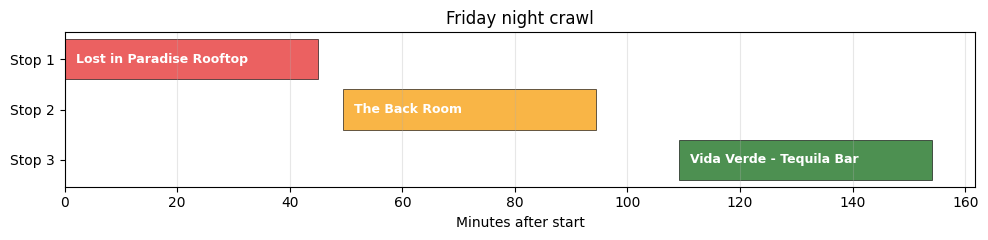

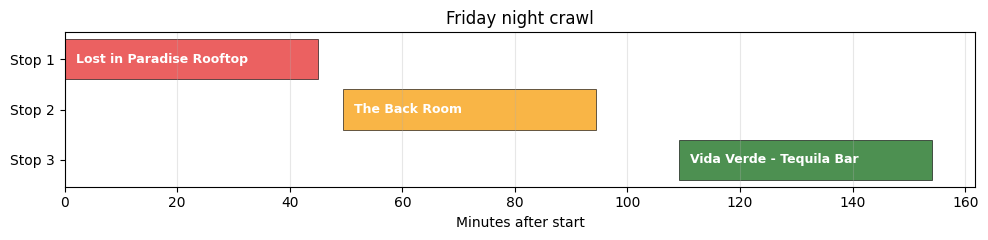

In [10]:
render_timeline(result.route, title='Friday night crawl')

### Per-stop score breakdown

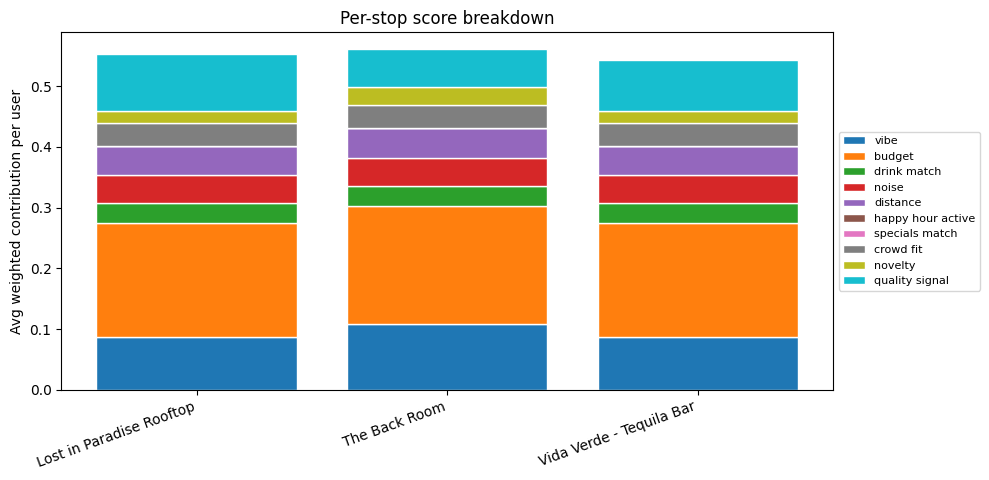

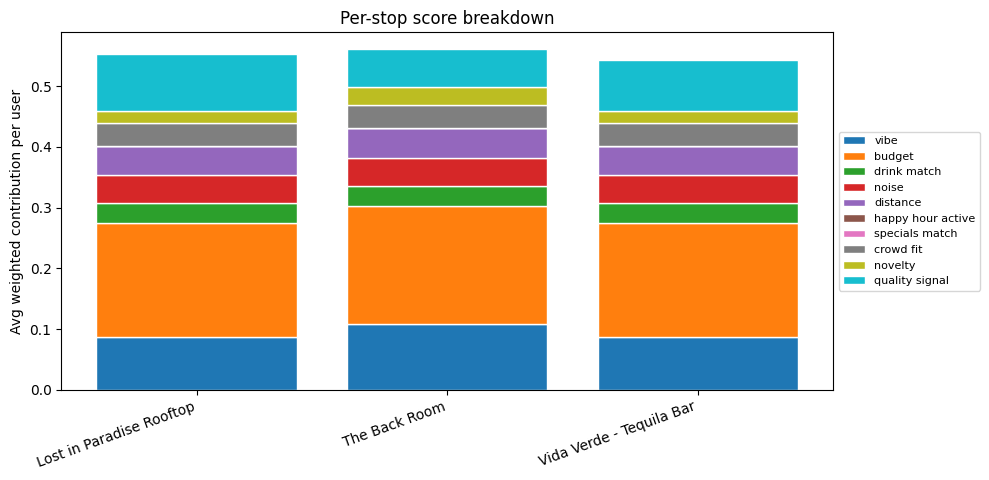

In [11]:
render_score_breakdown(result.route, result.traces['per_user_scores'])

## 5. Explanations

The top-level narrative:

In [12]:
display(Markdown(result.explanations.summary))

For Alice, Bob, Carol, here is a 3-stop crawl: Lost in Paradise Rooftop → The Back Room → Vida Verde - Tequila Bar. The plan captures 0 happy-hour/special windows and involves 1.0 miles of walking. The crawl threads through East Village, Lower East Side. Aggregated under the **copeland pairwise** strategy: Vibe preferences diverge significantly across the group (variance = 0.39). Copeland pairwise-majority finds a Condorcet-style consensus robust to this split.

The strategy rationale:

In [13]:
display(Markdown(result.explanations.children[0].summary))

We used **The candidate who wins every head-to-head** to aggregate 3 preferences. The group splits on vibe with no clear aligned center (The group is split on vibe with no clear aligned center — pairwise majority is more robust than summing.). The decisive factor: the group splits on vibe with no clear aligned center (vibe_variance=0.39 exceeded threshold 0.30). But approval veto was not chosen (rank A; dealbreaker_density=0.00 is below the 0.20 threshold — this rule didn't fire).

Per-stop explanations:

In [14]:
for i, child in enumerate(result.explanations.children[1:1 + len(result.route.stops)], 1):
    display(Markdown(f'**Stop {i}.** {child.summary}'))

**Stop 1.** We open at **Lost in Paradise Rooftop** at 7:08pm, a mid-priced, conversational spot in Lower East Side. The vibe matches what the group wanted (tags: airy, conversation, craft-cocktails), strong consensus pick (4.7★ over 6,621 reviews), and Alice rated this highest of the 3. The decisive factor: it's a widely-loved spot (4.7★ over 6,621 reviews). But it's over Bob's cap (~$14/drink over Bob's $12 cap) — Bob is paying over their cap at this stop. The closest alternative was 929.

**Stop 2.** Then **The Back Room** at 7:58pm, a mid-priced, conversational spot in Lower East Side. It's a widely-loved spot (4.2★ over 2,000 reviews) and Alice rated this highest of the 3. The decisive factor: the vibe matches what the group wanted (tags: conversation, craft-cocktails, date). But it's over Bob's cap (~$13/drink over Bob's $12 cap) — Bob is paying over their cap at this stop.

**Stop 3.** Closing at **Vida Verde - Tequila Bar** at 8:57pm, a mid-priced, conversational spot in East Village. It's a widely-loved spot (4.6★ over 4,210 reviews), strong consensus pick (4.6★ over 4,210 reviews), and Alice rated this highest of the 3. The decisive factor: the vibe matches what the group wanted (tags: conversation, craft-cocktails, date). But it's over Bob's cap (~$14/drink over Bob's $12 cap) — Bob is paying over their cap at this stop. The closest alternative was 929.

## 6. Option generation — *why not X instead?*

The system precomputes runner-ups, unlock hints, and counterfactuals. The user never
has to ask — the answers are already in the trace.

**Structural counterfactuals**  (what changes if the inputs shift?)

In [15]:
# The orchestrator ran these for us
cf_children = [c for c in result.explanations.children if c.summary == 'Counterfactuals']
if cf_children:
    for sub in cf_children[0].children:
        display(Markdown(f'• {sub.summary}'))
else:
    display(Markdown('(no counterfactuals produced)'))

• If the group had 30 more minutes, the same crawl emerges — same stops, same order.

• If each user had $10 more per drink, the same stops in the same order, but the group's overall score shifts +18% in group score.

**Strategy counterfactuals**  (who would win under each aggregation method?)

In [16]:
winners = result.traces.get('strategy_cf_winners', {})
if winners:
    rows = []
    for strat, bar_id in winners.items():
        if bar_id:
            bar = next((b for b in BARS if b.id == bar_id), None)
            rows.append({'strategy': strat, 'winner': bar.name if bar else '(no bar)', 
                          'chose this one?': '✓' if strat == result.route.strategy_used else ''})
    pd.DataFrame(rows)
else:
    pd.DataFrame()

## 7. Stakeholder taxonomy — per-user served-ness

Each user's view of how well the plan served *them* specifically.

In [17]:
display(Markdown(render_served_table(result.per_user_report)))

| User | mean score on route | top5 in route | vetoes respected | in budget stops |
|---|---|---|---|---|
| Alice | 0.668 | 3/5 | True | 3/3 |
| Bob | 0.396 | 0/5 | True | 0/3 |
| Carol | 0.592 | 1/5 | True | 3/3 |

## 8. Case-Based Reasoning — what archetype does this resemble?

In [18]:
top_cases = retrieve(group, CASES, top_k=3)
rows = []
for case, sim, breakdown in top_cases:
    rows.append({'case': case.name, 'similarity': round(sim, 3),
                 'narrative': case.success_narrative[:70] + '...'})
pd.DataFrame(rows)

,case,similarity,narrative
0,LES Speakeasy Ladder,0.776,"Opens with conversation, peaks in theatricalit..."
1,West Village Dignified Evening,0.614,Grown-up pacing; every stop supports real conv...
2,After-Dinner Nightcap,0.612,Just one well-chosen drink before heading home...


## 9. Edge cases — adversarial inputs

A decision system should fail gracefully. Three stress tests:

### 9.1 A user vetoes every cocktail bar

In [19]:
cocktail_ids = tuple(b.id for b in BARS if 'cocktail_bar' in b.bar_type)
alice_picky = UserPreference(**{**alice.__dict__, 'vetoes': cocktail_ids})
group_picky = GroupInput(users=[alice_picky, bob, carol],
                           start_time=group.start_time, end_time=group.end_time,
                           start_location=group.start_location, max_stops=3,
                           neighborhoods=group.neighborhoods)
r = plan_crawl(group_picky, bars=BARS, cases=CASES, rules=RULES, compute_counterfactuals=False)
print(f'Strategy: {r.route.strategy_used}')
print('Route:', ' → '.join(s.bar.name for s in r.route.stops) if r.route.stops else '(none)')
print(f'Excluded: {len(r.excluded_bars)}')
# None of the cocktail bars made it
route_types = {t for s in r.route.stops for t in s.bar.bar_type}
print(f'Route bar_types: {route_types}')

Strategy: copeland_pairwise
Route: Barcade → McSorley’s Old Ale House → Burp Castle
Excluded: 121
Route bar_types: {'generic_bar', 'pub'}


### 9.2 Impossible time window (30 minutes, 5 stops)

In [20]:
group_tight = GroupInput(users=[alice, bob], start_time=datetime(2026, 4, 24, 19, 0),
                           end_time=datetime(2026, 4, 24, 19, 30), max_stops=5)
r = plan_crawl(group_tight, bars=BARS, cases=CASES, rules=RULES, compute_counterfactuals=False)
print('Route length:', len(r.route.stops))
display(Markdown(r.explanations.summary))

Route length: 0


No route found — none of the candidate bars were feasible for your window. See the exclusion trace for the hard constraints that blocked the planner.

### 9.3 Total preference flat-line (all weights equal)

In [21]:
flat_user = UserPreference(name='Flat', vibe_weights={v: 0.5 for v in 
    ['chill', 'lively', 'conversation', 'unpretentious']},
    max_per_drink=15.0)
group_flat = GroupInput(users=[flat_user], start_time=group.start_time,
                          end_time=group.end_time, start_location=group.start_location,
                          max_stops=3)
r = plan_crawl(group_flat, bars=BARS, cases=CASES, rules=RULES, compute_counterfactuals=False)
print('Route:', ' → '.join(s.bar.name for s in r.route.stops) if r.route.stops else '(none)')
print(f'Strategy: {r.route.strategy_used}')
# When preferences are flat, novelty + quality_signal + distance dominate
print('→ With flat vibes, the decision falls back to novelty, quality_signal, and distance.')

Route: duckduck → McSorley’s Old Ale House → Barcade
Strategy: utilitarian_sum
→ With flat vibes, the decision falls back to novelty, quality_signal, and distance.


## 10. Reflection — what this system does well, post-Phase-4

What this system does well:

- **Every decision has a trace.** The route, the strategy, the exclusions —
  each carries its provenance. A skeptical user can read the explanation and
  check it against the data.
- **The meta-selector earns its keep.** Rather than hard-coding one aggregation
  method, the system reasons about *which* method fits the group's disagreement
  profile, and explains that choice — including which alternatives almost fired,
  with explicit `why_not_chosen` strings (Phase 1's `StrategyDecision`).
- **CBR closes the R-loop.** Phase 3's `adapt_case` modifies the retrieved
  archetype to fit the group (length / vibe injection / neighborhood
  retargeting), seeds the router as a soft prior, and surfaces every
  adaptation in the explanation tree. The retrieved archetype is no longer
  decorative — it influences the route, with every modification logged.
- **Explanations are structured, not templated.** Phase 2's `Argument` /
  `Premise` / `render_argument` triple separates the reasoning shape
  (conclusion + supporting + decisive + opposing + sacrifice + runner-up)
  from the prose layer. Direction-aware renderers prevent dishonest
  phrasing like *"it fits the budget (over the cap)"*.
- **The system can be talked back to.** Phase 4's `replan_with_reactions`
  takes accept/reject/swap/lock reactions, updates user preferences with a
  bounded multiplicative rule (capped at 2× original; budget cap widened by
  half the overshoot on accept), preserves locked stops as fixed waypoints,
  and produces a `DeltaArgument` that attributes every change in the new
  plan to either a reaction or a named preference-update ripple.
  Unattributable changes are flagged as bugs, not hidden.

What it still doesn't do:

- Hours, happy hours, and specials are *plausible category defaults*, not
  live data. See WRITEUP §8 Limitations.
- Locked-stop replan path skips global 2-opt (the user pinned them).
- Single-night crawls only — no Friday-Saturday-Sunday arc model yet.

The thesis, restated: **The intelligence of a decision system lives in its
explanations, not its ranking function.** A recommender returns a list. A
decision system can tell you what lost, what would have to change, why
someone else would choose differently — and when you push back, it can
update its model of you in a way you can read, undo, and trust.

## 11. Post-proposal additions: Phase 1–4 demos

Four phases were implemented after the proposal was approved. Each is demoed below
on the same group from §1 (or a tighter scenario where the feature requires it).

### 11.1 Phase 1 — `StrategyDecision` + deeper analysis

The meta-selector returns a structured object, not a tuple. When the chosen plan's
mean normalized runner-up gap falls below the configured threshold, the rank flips
to `E` and `requires_deeper_analysis=True`, signalling the caller to invoke
`deeper_analysis(plan_result)`.

In [22]:
from src.decision_system import deeper_analysis

decision = result.traces['strategy_decision']
print(f'Strategy: {decision.narrative_name}')
print(f'Rank:     {decision.rank}')
print(f'Requires deeper analysis: {decision.requires_deeper_analysis}')
print(f'Plan margin (mean normalized runner-up gap): {result.traces.get("plan_margin", "N/A"):.3f}')
print()

# Force deeper analysis with a permissive threshold so the demo always runs
import copy
diff = deeper_analysis(result, rules=RULES)
print(f'Deeper analysis — per-stop diff:')
for d in diff['stop_diffs']:
    w, ru = d['winner'], d['runner_up']
    print(f'  Stop {d["stop_index"]+1}: WIN  {w["bar_name"]:30s} ({w["neighborhood"]}, {w["price_tier"]}) score={w["group_score"]:.3f}')
    if ru:
        print(f'           RU   {ru["bar_name"]:30s} ({ru["neighborhood"]}, {ru["price_tier"]}) rel_gap={ru["relative_gap"]:.3f}')
        print(f'           top criteria gaps: {ru["top_criteria_gaps"]}')
        print(f'           unlock hint: {ru["unlock_hint"]}')

Strategy: The candidate who wins every head-to-head
Rank:     B
Requires deeper analysis: False
Plan margin (mean normalized runner-up gap): 0.097

Deeper analysis — per-stop diff:
  Stop 1: WIN  Lost in Paradise Rooftop       (Lower East Side, moderate) score=30.000
           RU   929                            (Lower East Side, premium) rel_gap=0.097
           top criteria gaps: [('quality_signal', 0.39569999999999994), ('novelty', -0.19999999999999996), ('vibe', -0.07051507420834024)]
           unlock hint: prioritized novelty
  Stop 2: WIN  The Back Room                  (Lower East Side, moderate) score=31.000
           RU   929                            (Lower East Side, premium) rel_gap=0.129
           top criteria gaps: [('quality_signal', 0.08709999999999996), ('budget', 0.06783770135184468), ('distance', 0.008259465564187773)]
           unlock hint: (runner-up doesn't beat the winner on any single criterion)
  Stop 3: WIN  Vida Verde - Tequila Bar       (East Village, 

### 11.2 Phase 2 — Structured `Argument` internals

`build_stop_argument` returns the structured object that `explain_stop` linearizes.
Below is the raw structure for stop 1 — its supporting and opposing premises,
each with subject, criterion, direction, magnitude, and concrete evidence.

In [23]:
from src.explanation_engine import build_stop_argument
from src.argument import render_argument

stop = result.route.stops[0]
arg = build_stop_argument(
    0, stop, result.route, result.traces['per_user_scores'],
    stop.runner_up, RULES, users=group.users,
)

print(f'CONCLUSION: {arg.conclusion}\n')
print('SUPPORTING PREMISES:')
for p in arg.supporting:
    marker = '*' if p is arg.decisive_premise else ' '
    print(f'  {marker} [{p.subject:20s}] {p.criterion:20s} mag={p.magnitude:.2f}  "{p.evidence}"')
print()
if arg.opposing:
    print('OPPOSING PREMISES:')
    for p in arg.opposing:
        print(f'    [{p.subject:20s}] {p.criterion:20s} mag={p.magnitude:.2f}  "{p.evidence}"')
print()
if arg.sacrifice:
    print(f'SACRIFICE: {arg.sacrifice}')
print()
print('RENDERED PROSE:')
print(' ', render_argument(arg))

CONCLUSION: We open at **Lost in Paradise Rooftop** at 7:08pm, a mid-priced, conversational spot in Lower East Side

SUPPORTING PREMISES:
  * [the group           ] quality_signal       mag=0.09  "4.7★ over 6,621 reviews"
    [the group           ] vibe                 mag=0.09  "tags: airy, conversation, craft-cocktails"
    [the group           ] quality_consensus    mag=0.20  "4.7★ over 6,621 reviews"
    [Alice               ] dominant_user        mag=0.30  "highest of the 3"

OPPOSING PREMISES:
    [Bob                 ] budget               mag=0.50  "~$14/drink over Bob's $12 cap"
    [929                 ] quality_signal       mag=0.30  "runner-up wins on quality signal by 0.40"

SACRIFICE: Bob is paying over their cap at this stop

RENDERED PROSE:
  We open at **Lost in Paradise Rooftop** at 7:08pm, a mid-priced, conversational spot in Lower East Side. The vibe matches what the group wanted (tags: airy, conversation, craft-cocktails), strong consensus pick (4.7★ over 6,621 rev

### 11.3 Phase 3 — Adaptive CBR (R-loop closed)

`adapt_case` transforms the top-retrieved archetype to fit the group:
length adaptation (trim/extend), vibe injection for must-have user vibes
absent from the archetype, and neighborhood retargeting to nearest allowed
neighborhood. Every change is logged.

The adapted sequence is then a soft prior in the router (per-stage vibe
match × `routing_config.cbr_seed_bonus`).

In [24]:
adapted = result.traces.get('adapted_case')
if adapted is None:
    print('(no CBR adaptation in this plan)')
else:
    print(f'Source archetype: {adapted.source_case_name} (id={adapted.source_case_id})')
    print(f'Similarity:       {adapted.similarity:.3f}')
    print(f'Breakdown:        {adapted.similarity_breakdown}')
    print()
    print(f'ADAPTED SEQUENCE ({len(adapted.adapted_sequence)} stages):')
    for i, stage in enumerate(adapted.adapted_sequence):
        role = stage.get('role', 'unnamed')
        bts  = ', '.join(stage.get('bar_type', []))
        vp   = stage.get('vibe_profile', {})
        top  = sorted(vp.items(), key=lambda kv: -kv[1])[:3]
        print(f'  Stage {i} [{role:10s}] bar_type=[{bts}] top vibes={top}')
    print()
    if adapted.adaptations:
        print(f'ADAPTATIONS APPLIED ({len(adapted.adaptations)}):')
        for ad in adapted.adaptations:
            print(f'  • {ad.field_changed}')
            print(f'    {ad.reason}')
    if adapted.unadapted_stages:
        print(f'UNADAPTED STAGES (no feasible bars): {adapted.unadapted_stages}')

Source archetype: LES Speakeasy Ladder (id=case_les_speakeasy_ladder)
Similarity:       0.776
Breakdown:        {'size': 1.0, 'budget': 1.0, 'neighborhood': 1.0, 'vibe': 0.5011258005438487}

ADAPTED SEQUENCE (3 stages):
  Stage 0 [warm_up   ] bar_type=[cocktail_bar] top vibes=[('intimate', 0.9), ('conversation', 0.9), ('polished', 0.8)]
  Stage 1 [main      ] bar_type=[cocktail_bar, themed] top vibes=[('dim', 0.9), ('theatrical', 0.8), ('historic', 0.6)]
  Stage 2 [nightcap  ] bar_type=[wine_bar, lounge] top vibes=[('intimate', 0.9), ('cozy', 0.8), ('natural-wine', 0.6)]

ADAPTATIONS APPLIED (3):
  • solution_sequence[0].vibe_profile
    group has a must-have vibe 'hidden-gem' that the archetype didn't include; injected into the 'warm_up' stage
  • solution_sequence[0].vibe_profile
    group has a must-have vibe 'lively' that the archetype didn't include; injected into the 'warm_up' stage
  • solution_sequence[0].vibe_profile
    group has a must-have vibe 'unpretentious' that the arch

### 11.4 Phase 4 — Dialogic replan with bounded preference learning

`replan_with_reactions` takes accept/reject/swap reactions and re-plans with
updated preferences. Locked stops are preserved exactly. Below: Alex rejects
stop 1 (so any criterion where stop 1 was in his bottom quartile gets a 1.3×
weight bump, capped at 2× original); Bob locks stop 2.

In [25]:
from src.dialogic import replan_with_reactions
from src.models import Reaction

if len(result.route.stops) < 2:
    print('Plan has fewer than 2 stops; skipping replan demo.')
else:
    reactions = [
        Reaction(user_id='Alice', stop_index=0, verdict='reject',
                 optional_reason='too loud for me'),
        Reaction(user_id='Bob',   stop_index=1, verdict='accept', lock=True),
    ]
    new_result = replan_with_reactions(
        result, reactions, group, bars=BARS, cases=CASES, rules=RULES,
    )

    pref_child = next((c for c in new_result.explanations.children
                        if c.evidence.get('kind') == 'preference_updates'), None)
    delta_child = next((c for c in new_result.explanations.children
                         if c.evidence.get('kind') == 'delta'), None)
    if pref_child:
        print('PREFERENCE UPDATES:')
        print(pref_child.summary)
        print()
    if delta_child:
        print('DELTA NARRATIVE:')
        print(delta_child.summary)
        print()
    print('NEW ROUTE:')
    for i, s in enumerate(new_result.route.stops, 1):
        marker = ' (locked)' if any(r.lock and r.stop_index == i-1 for r in reactions) else ''
        print(f'  {i}. {s.bar.name:30s} at {s.arrival.strftime("%H:%M")}{marker}')

PREFERENCE UPDATES:
Based on your reactions, I updated these preferences:
  • Alice's vibe weight rose from 0.10 to 0.13. Reason: Alice rejected stop 1, which scored in their bottom quartile on 'vibe'; bumped the weight by 30% (capped at 2.0× original)
  • Alice's budget weight rose from 0.10 to 0.13. Reason: Alice rejected stop 1, which scored in their bottom quartile on 'budget'; bumped the weight by 30% (capped at 2.0× original)
  • Alice's drink match weight rose from 0.10 to 0.13. Reason: Alice rejected stop 1, which scored in their bottom quartile on 'drink_match'; bumped the weight by 30% (capped at 2.0× original)
  • Alice's noise weight rose from 0.10 to 0.13. Reason: Alice rejected stop 1, which scored in their bottom quartile on 'noise'; bumped the weight by 30% (capped at 2.0× original)
  • Alice's happy hour active weight rose from 0.10 to 0.13. Reason: Alice rejected stop 1, which scored in their bottom quartile on 'happy_hour_active'; bumped the weight by 30% (capped at 

Every change in the new plan is attributed to either a reaction or a named
preference-update ripple. An unattributable change would be flagged in
`delta.unattributed` and treated as a bug — never hidden.